<a href="https://colab.research.google.com/github/icy-agarwal/AIML/blob/main/DAY10_to_DAY14_COVID_EDA/covid_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# **DAY 10: DATA LOADING AND UNDERSTANDING**

In [2]:
df = pd.read_csv('country_vaccinations.csv')
df.head()

,country,iso_code,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations_raw,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,daily_vaccinations_per_million,vaccines,source_name,source_website
0,Afghanistan,AFG,2021-02-22,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
1,Afghanistan,AFG,2021-02-23,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
2,Afghanistan,AFG,2021-02-24,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
3,Afghanistan,AFG,2021-02-25,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
4,Afghanistan,AFG,2021-02-26,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/


In [4]:
print(df.shape)

(86512, 15)


In [5]:
print(df.columns)

Index(['country', 'iso_code', 'date', 'total_vaccinations',
       'people_vaccinated', 'people_fully_vaccinated',
       'daily_vaccinations_raw', 'daily_vaccinations',
       'total_vaccinations_per_hundred', 'people_vaccinated_per_hundred',
       'people_fully_vaccinated_per_hundred', 'daily_vaccinations_per_million',
       'vaccines', 'source_name', 'source_website'],
      dtype='object')


In [6]:
print(df.dtypes)

country                                 object
iso_code                                object
date                                    object
total_vaccinations                     float64
people_vaccinated                      float64
people_fully_vaccinated                float64
daily_vaccinations_raw                 float64
daily_vaccinations                     float64
total_vaccinations_per_hundred         float64
people_vaccinated_per_hundred          float64
people_fully_vaccinated_per_hundred    float64
daily_vaccinations_per_million         float64
vaccines                                object
source_name                             object
source_website                          object
dtype: object


In [7]:
print(df.isnull().sum())

country                                    0
iso_code                                   0
date                                       0
total_vaccinations                     42905
people_vaccinated                      45218
people_fully_vaccinated                47710
daily_vaccinations_raw                 51150
daily_vaccinations                       299
total_vaccinations_per_hundred         42905
people_vaccinated_per_hundred          45218
people_fully_vaccinated_per_hundred    47710
daily_vaccinations_per_million           299
vaccines                                   0
source_name                                0
source_website                             0
dtype: int64


In [9]:
df.describe()

,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations_raw,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,daily_vaccinations_per_million
count,4.360700e+04,4.129400e+04,3.880200e+04,3.536200e+04,8.621300e+04,43607.000000,41294.000000,38802.000000,86213.000000
mean,4.592964e+07,1.770508e+07,1.413830e+07,2.705996e+05,1.313055e+05,80.188543,40.927317,35.523243,3257.049157
std,2.246004e+08,7.078731e+07,5.713920e+07,1.212427e+06,7.682388e+05,67.913577,29.290759,28.376252,3934.312440
min,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,5.264100e+05,3.494642e+05,2.439622e+05,4.668000e+03,9.000000e+02,16.050000,11.370000,7.020000,636.000000
50%,3.590096e+06,2.187310e+06,1.722140e+06,2.530900e+04,7.343000e+03,67.520000,41.435000,31.750000,2050.000000
75%,1.701230e+07,9.152520e+06,7.559870e+06,1.234925e+05,4.409800e+04,132.735000,67.910000,62.080000,4682.000000
max,3.263129e+09,1.275541e+09,1.240777e+09,2.474100e+07,2.242429e+07,345.370000,124.760000,122.370000,117497.000000


# **DAY 11: DATA CLEANING**

In [10]:
df['date'] = pd.to_datetime(df['date'])

In [11]:
cols_to_fill = [
    'total_vaccinations',
    'people_vaccinated',
    'people_fully_vaccinated',
    'total_vaccinations_per_hundred',
    'people_vaccinated_per_hundred',
    'people_fully_vaccinated_per_hundred'
]
df[cols_to_fill] = df.groupby('country')[cols_to_fill].ffill()

In [12]:
df = df.dropna(subset=['daily_vaccinations'])

In [13]:
print(df.isnull().sum())
print(df.shape)

country                                    0
iso_code                                   0
date                                       0
total_vaccinations                         0
people_vaccinated                        771
people_fully_vaccinated                10265
daily_vaccinations_raw                 50851
daily_vaccinations                         0
total_vaccinations_per_hundred             0
people_vaccinated_per_hundred            771
people_fully_vaccinated_per_hundred    10265
daily_vaccinations_per_million             0
vaccines                                   0
source_name                                0
source_website                             0
dtype: int64
(86213, 15)


# **DAY 12: FIVE INSIGHTS FROM THE DATA**

In [15]:
top10 = df.groupby('country')['total_vaccinations'].max().sort_values(ascending=False).head(10)
print(top10)

country
China            3.263129e+09
India            1.834501e+09
United States    5.601818e+08
Brazil           4.135596e+08
Indonesia        3.771089e+08
Japan            2.543456e+08
Bangladesh       2.436427e+08
Pakistan         2.193686e+08
Vietnam          2.031444e+08
Mexico           1.919079e+08
Name: total_vaccinations, dtype: float64


/tmp/ipykernel_1099/3720433191.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, palette='viridis')


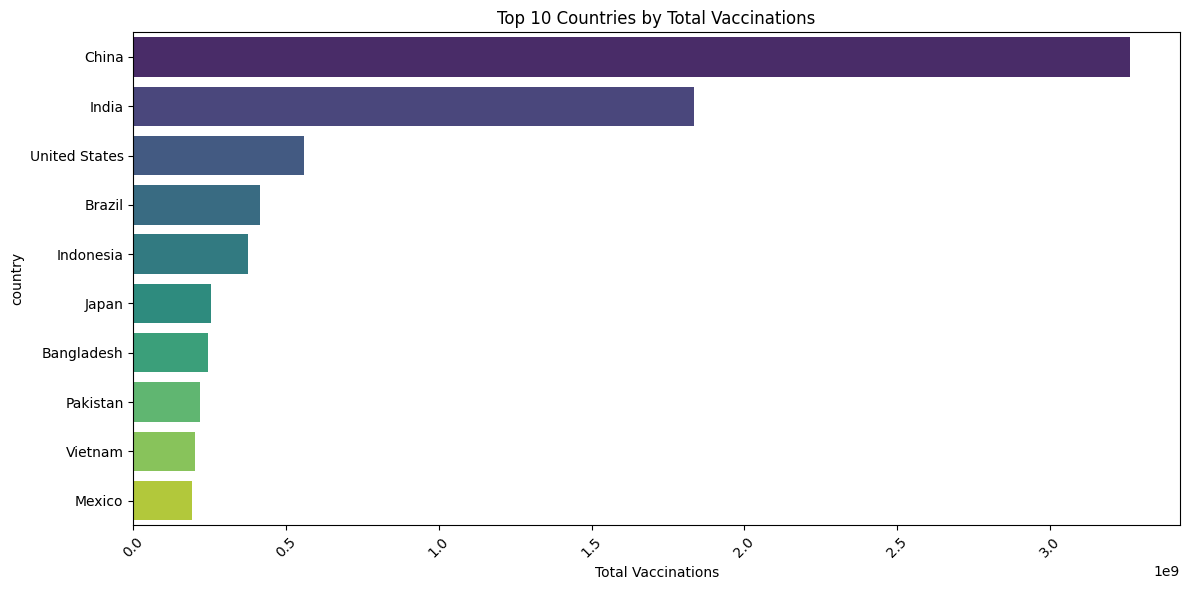

In [18]:
plt.figure(figsize=(12, 6))
sns.barplot(x=top10.values, y=top10.index, palette='viridis')
plt.title('Top 10 Countries by Total Vaccinations')
plt.xlabel('Total Vaccinations')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('insight1_top10.png')
plt.show()

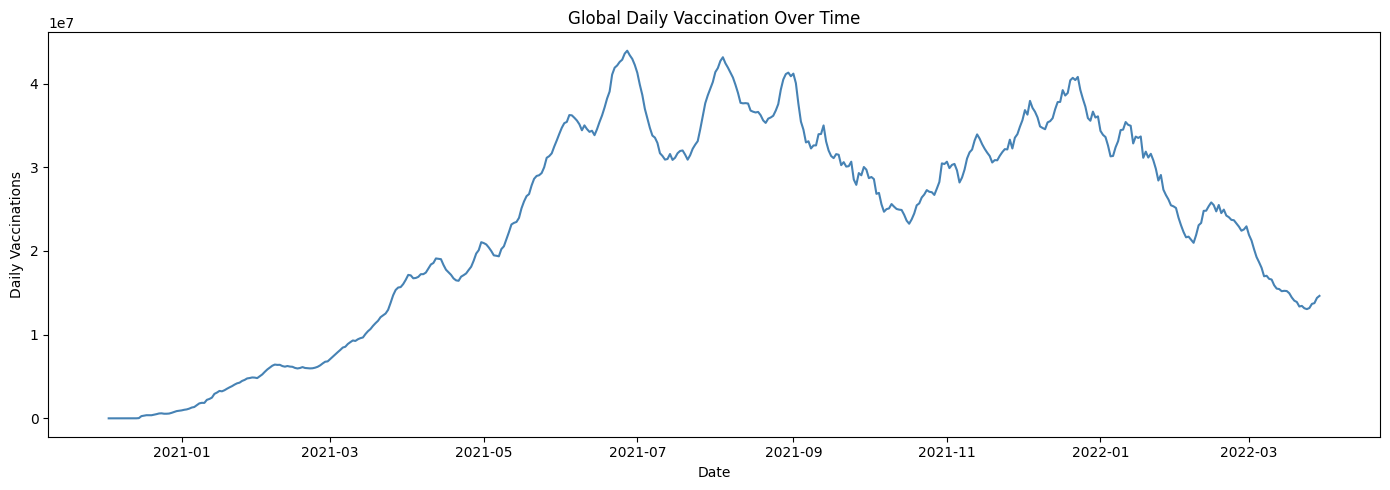

In [21]:
global_daily=df.groupby('date')['daily_vaccinations'].sum()
plt.figure(figsize=(14,5))
plt.plot(global_daily.index, global_daily.values, color='steelblue')
plt.title('Global Daily Vaccination Over Time')
plt.xlabel('Date')
plt.ylabel('Daily Vaccinations')
plt.tight_layout()
plt.savefig('insight2_global_trend.png')
plt.show()

In [20]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [22]:
fully_vax = df.groupby('country')['people_fully_vaccinated_per_hundred'].max().dropna().sort_values(ascending=False).head(20)

/tmp/ipykernel_1099/2242644223.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fully_vax.values, y = fully_vax.index, palette='coolwarm')


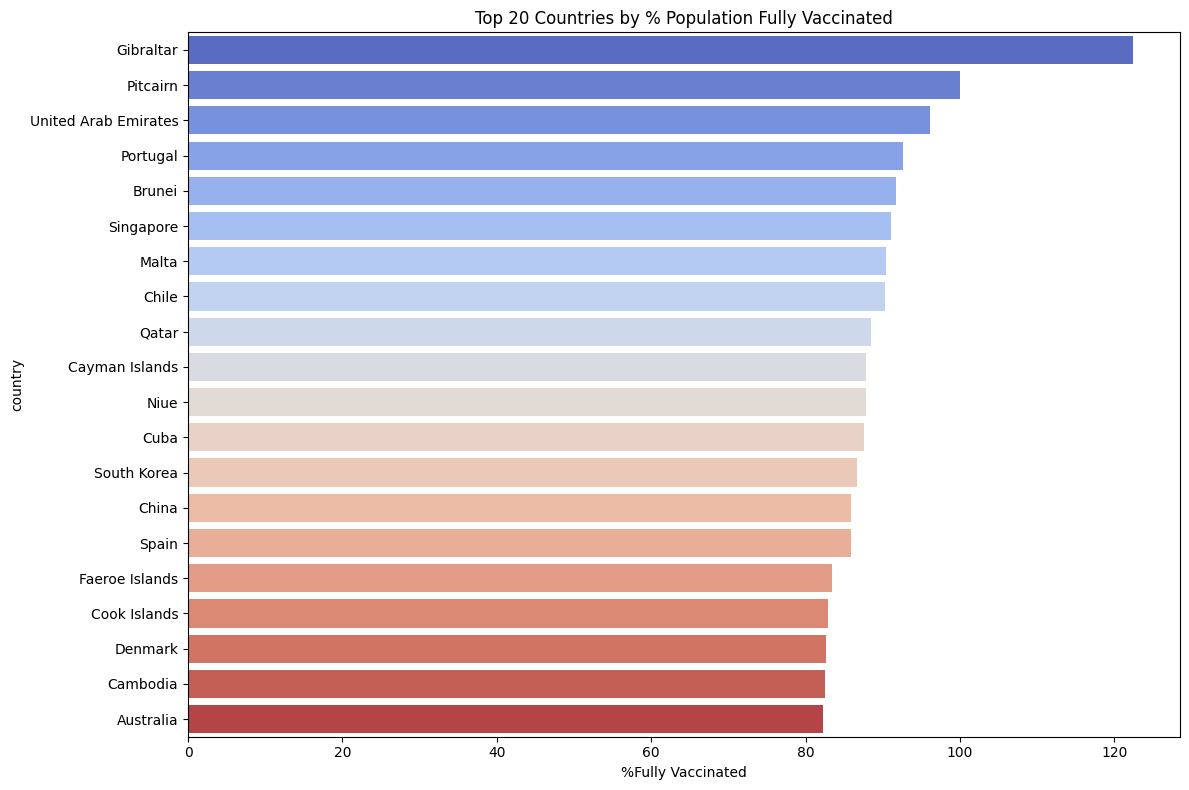

In [23]:
plt.figure(figsize=(12,8))
sns.barplot(x=fully_vax.values, y = fully_vax.index, palette='coolwarm')
plt.title("Top 20 Countries by % Population Fully Vaccinated")
plt.xlabel('%Fully Vaccinated')
plt.tight_layout()
plt.savefig('insight3_fully_vax.png')
plt.show()

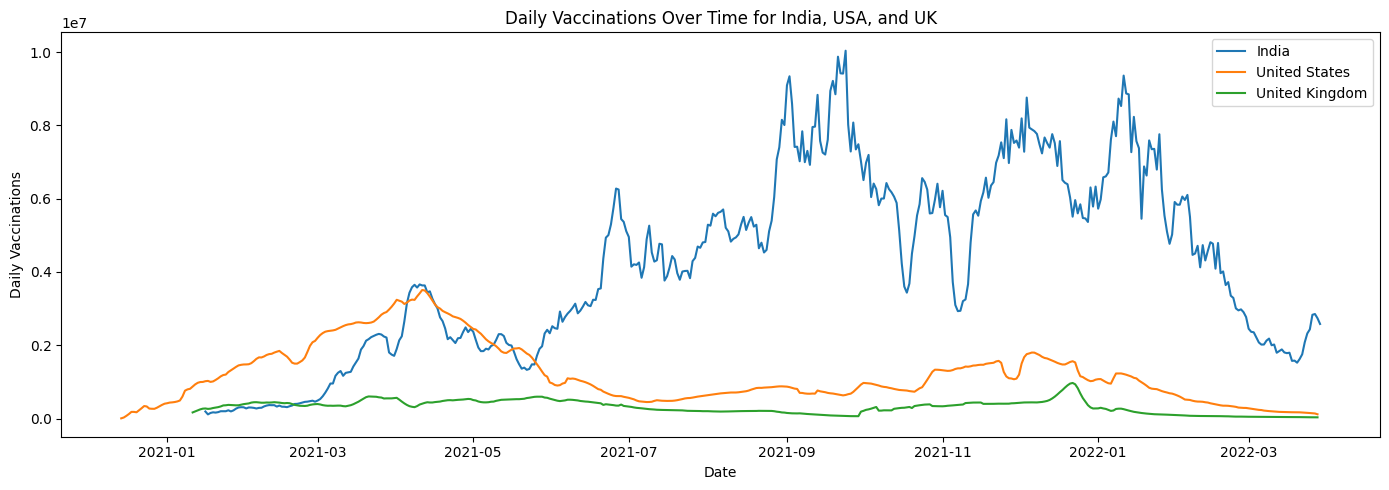

In [25]:
countries = ['India', 'United States', 'United Kingdom']
filtered = df[df['country'].isin(countries)]

plt.figure(figsize=(14,5))
for country in countries:
  data = filtered[filtered['country'] == country]
  plt.plot(data['date'], data['daily_vaccinations'], label=country)

plt.title('Daily Vaccinations Over Time for India, USA, and UK')
plt.xlabel('Date')
plt.ylabel('Daily Vaccinations')
plt.legend()
plt.tight_layout()
plt.savefig('insight4_country_trend.png')
plt.show()

/tmp/ipykernel_1099/3901025331.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vaccine_counts.values, y=vaccine_counts.index, palette='magma')


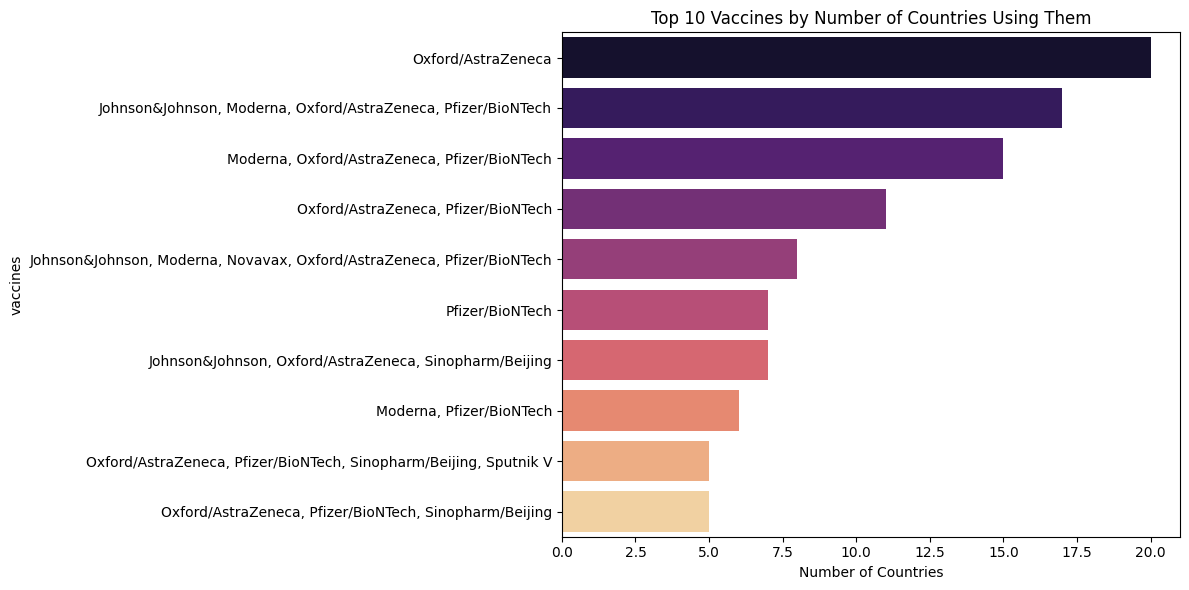

In [26]:
vaccine_counts = df.groupby('vaccines')['country'].nunique().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=vaccine_counts.values, y=vaccine_counts.index, palette='magma')
plt.title('Top 10 Vaccines by Number of Countries Using Them')
plt.xlabel('Number of Countries')
plt.tight_layout()
plt.savefig('insight5_vaccines.png')
plt.show()